# When Coinbase pays more for Bitcoin than Binance… does it *mean* something? 🪙
### The "Coinbase premium" — the famous footprint of the US institutional bid, tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Dead_since_the_ETFs%3F: Busted](https://img.shields.io/badge/Dead_since_the_ETFs%3F-Busted-8b949e?style=flat-square)

Same Bitcoin, two shops. On **Coinbase** (the big US exchange) it might cost $60,024; on **Binance** (the global one) $59,961 at the exact same second. That tiny gap — a few hundredths of a percent — is the **Coinbase premium**, and during the 2020-21 bull run it became crypto's favourite tea leaf: *"Coinbase is trading rich — the American institutions are buying — get in before the wave."*

It's a lovely story with a real mechanism behind it (someone buying billions in actual dollars really does push the dollar venue first). The question a desk has to ask is colder: **does today's premium tell you anything about tomorrow's price?**

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the winsorized robustness and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **One caveat up front.** The Binance side is priced in **USDT** (Tether), not dollars. When Tether itself wobbles, the "premium" moves with zero Coinbase flow — that's most of the wild ±2-5% swings of 2017-18. We name it and test around it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from coinbase_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    DF = data.load_real()                          # pinned as-of; cache-first
    PREM = st.premium_bps(DF)
    RET = st.log_returns(DF)
else:
    DF = PREM = RET = None
print("real cb/bn cache present:", HAVE_REAL,
      "| days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2017-08-17', 'end': '2026-06-30', 'asof': '2026-06-30', 'n_days': 3240, 'years': 8.9, 'fingerprint': '73bf2b138404', 'prem_mean': 1.54, 'prem_sd': 64.0, 'prem_min': -535.2, 'prem_max': 1335.3, 'ac1': 0.71, 'contemp_corr': 0.077, 'contemp_t': 1.91, 'yearly': [(2017, 107.37, 198.66, 76), (2018, -33.84, 110.9, 42), (2019, -4.45, 57.85, 54), (2020, 5.95, 14.16, 72), (2021, 5.94, 6.71, 88), (2022, -1.08, 7.04, 61), (2023, 3.19, 9.6, 75), (2024, -0.02, 6.82, 52), (2025, 0.43, 4.78, 60), (2026, -5.62, 6.28, 20)], 'neg2026': (145, 181), 'pred_raw': [(1, 12.47, 1.42), (2, 23.08, 1.76), (3, 37.97, 2.09), (5, 53.36, 1.48), (7, 61.37, 1.16)], 'pred_wins': [(1, 20.81, 2.3), (2, 32.98, 2.22), (3, 46.99, 2.1), (5, 68.38, 1.71), (7, 90.72, 1.63)], 'pred_chg': [(1, 2.39, 0.22), (2, -3.22, -0.26), (3, -2.04, -0.17), (5, 12.19, 1.12), (7, 6.5, 0.62)], 'winsor_lo': -215.8, 'winsor_hi': 178.7, 'split_rich': 17.77, 'split_cheap': 0.18, 'split_welch': 1.4, 'n_rich': 1533, 'n_cheap': 1676, 'overlay': [(5.0, 7.38, 1.67, 0.56, 30.9, 3.55, 1.13), (10.0, 6.34, 1.43, 0.48, 26.1, 2.52, 0.8), (25.0, 3.24, 0.73, 0.24, 12.6, -0.58, -0.18)], 'gross_bps': 8.41, 'exposure': 47.3, 'turnover': 76, 'bh_bps': 8.07, 'bh_sharpe': 0.43, 'bh_ann': 34.3, 'zrobust': [(20, 10.63, 2.52, 6.68, 2.15), (63, 6.34, 1.43, 2.52, 0.8), (126, 8.54, 1.96, 4.58, 1.48)], 'rand_mean': -1.46, 'rand_sd': 2.98, 'rand_t': -0.33, 'rand_seeds': 20, 'eras': [('2017-2019', 867, 0.85, 122.83, 19.89, 1.21, 6.02, 0.86), ('2020-2021', 731, 5.95, 11.08, 10.43, 0.56, -6.04, -0.79), ('2022', 365, -1.08, 7.04, 4.95, 0.29, 7.14, 0.69), ('2023+', 1277, 0.23, 7.68, 29.15, 2.87, 1.23, 0.34), ('2024+ (ETF era)', 912, -0.95, 6.4, 16.9, 1.8, 4.24, 0.97)], 'slope_pre': 0.175, 'slope_post': 3.793, 'slope_ratio': 22, 'slope_diff_t': 2.72, 'syn': [(0.0, 4.75, 0.75), (0.003, 34.05, 5.35)]}


real cb/bn cache present: True | days: 3240


## The answer first

| Question | Answer |
|---|---|
| Was the 2020-21 "institutional bid" real? | **Yes, as a footprint.** Coinbase sat rich on 72-88% of days through 2020-21 — the folklore's *shape* is genuinely on the tape. |
| Does the premium **predict** the next move? | **Barely.** The lean is always in the right direction, but at normal statistical standards it's a **whisper, not a signal** — about 1.4 sigma where the desk demands 2. |
| Can you trade it? | **No.** A rule that holds BTC only when Coinbase is rich earns less than just holding BTC, and its "timing skill" is indistinguishable from a coin-flip twin once you charge fees. |
| Did the 2024 ETFs kill it? | **Surprise: no.** The premium *shrank* ~10-20× — but per unit of premium it now says **22× more** than it used to. Smaller footprint, sharper meaning. |

> The honest verdict: a **real coincident indicator** — it tells you who is buying *right now* — dressed up by folklore as a crystal ball it never was.

## 1 · The claim

> *"US institutions clear their Bitcoin in actual dollars, mostly on Coinbase. When they buy size, Coinbase prints **above** Binance. Watch the premium and you front-run the wave."*

This is the **Coinbase Premium Gap**, popularised by the analytics firm CryptoQuant during the Saylor/Tesla accumulation winter of 2020-21, and quoted in market wraps ever since. We rebuild it from the two exchanges' own public price feeds — **8.9 years, 3,240 days**, every day both venues printed a close at the same UTC instant.

*(Cousin study, different object: [294-coinbase-rank](../../294-coinbase-rank/README.md) tested the Coinbase **app's App-Store ranking** — retail FOMO. This is the **exchange price gap** — the institutional footprint.)*

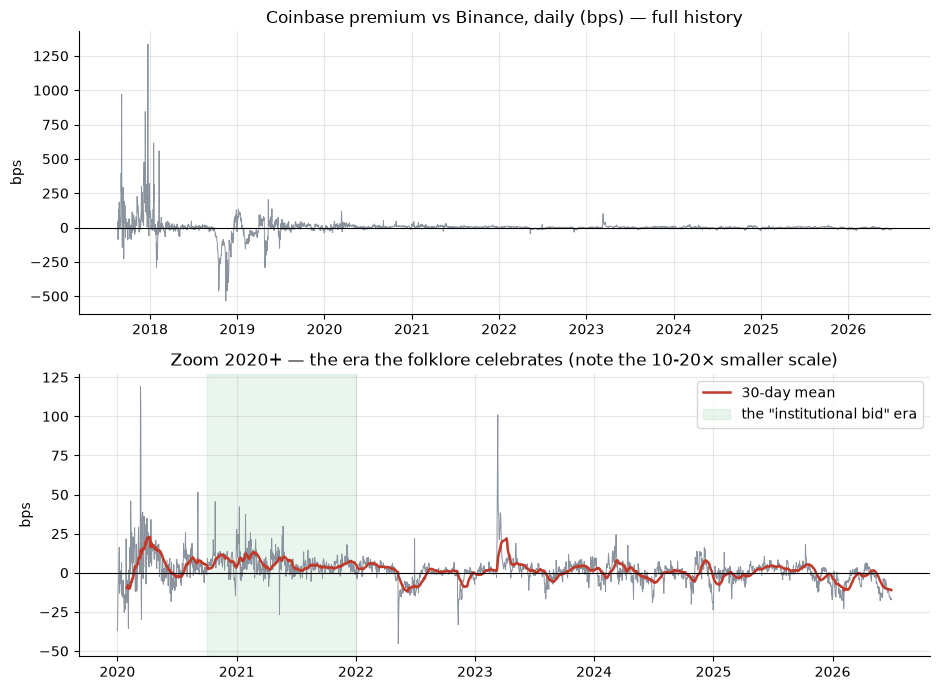

In [2]:
# The premium, 2017 -> 2026 (daily, bps). The eye needs two scales: the wild early years
# and the compressed modern era -- so we show both.
if HAVE_REAL:
    fig, axes = plt.subplots(2, 1, figsize=(9.5, 7), sharex=False,
                             gridspec_kw={'height_ratios': [1, 1]})
    ax = axes[0]
    ax.plot(PREM.index, PREM.values, color=GREY, lw=0.7)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title('Coinbase premium vs Binance, daily (bps) — full history')
    ax.set_ylabel('bps')
    ax = axes[1]
    modern = PREM[PREM.index >= '2020-01-01']
    ax.plot(modern.index, modern.values, color=GREY, lw=0.7)
    roll = modern.rolling(30).mean()
    ax.plot(roll.index, roll.values, color=RED, lw=1.8, label='30-day mean')
    ax.axhline(0, color='k', lw=0.8)
    ax.axvspan(pd.Timestamp('2020-10-01'), pd.Timestamp('2021-12-31'),
               color=GREEN, alpha=0.10, label='the "institutional bid" era')
    ax.set_title('Zoom 2020+ — the era the folklore celebrates (note the 10-20\u00d7 smaller scale)')
    ax.set_ylabel('bps')
    ax.legend(loc='upper right')
    plt.tight_layout(); plt.show()
else:
    print('cache missing - see docs/results.md:', R['prem_mean'], 'bps mean,', R['prem_sd'], 'bps sd')


## 2 · The regime story is *true*

Year by year, the premium really does tell the story everyone remembers:

- **2017-18** — chaos: swings of ±2-5%. Mostly **Tether noise**, not institutions (the Binance leg is USDT).
- **2020-21** — the **institutional bid**: Coinbase rich on **72-88% of days**. Saylor, Tesla, the corporate-treasury wave — the footprint is unmistakable.
- **2022+** — compression: arbitrage desks matured and the gap shrank to single-digit bps.
- **2026 H1** — the mirror image: Coinbase **cheap on 145 of 181 days** (mean −5.6 bps). The US bid, on this tell, is *absent*.

So the premium is a genuine **coincident** gauge. The folklore's money claim is stronger though: that it **leads**.

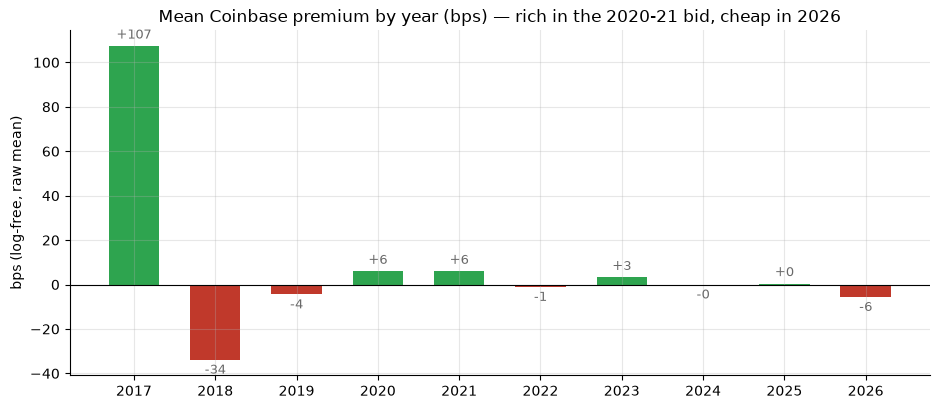

2026 H1: Coinbase cheap on 145 of 181 days


In [3]:
# Yearly mean premium -- the regime narrative in one bar chart (green rich, red cheap).
yrs = [str(y) for y, m, s, p in R['yearly']]
means = [m for y, m, s, p in R['yearly']]
colors = [GREEN if m > 0 else RED for m in means]
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.bar(yrs, means, color=colors, width=0.62)
ax.axhline(0, color='k', lw=0.8)
for i, (y, m, s, p) in enumerate(R['yearly']):
    va = 'bottom' if m >= 0 else 'top'
    off = 2 if m >= 0 else -2
    ax.annotate(f'{m:+.0f}', (i, m + off), ha='center', va=va, fontsize=9, color='dimgray')
ax.set_title('Mean Coinbase premium by year (bps) — rich in the 2020-21 bid, cheap in 2026')
ax.set_ylabel('bps (log-free, raw mean)')
plt.tight_layout(); plt.show()
print('2026 H1: Coinbase cheap on %d of %d days' % R['neg2026'])


## 3 · Does it *lead*? The uncomfortable middle

Take every day since 2017, note the premium at the close, and ask what Bitcoin did **the next day** (and over the next week). The answer is maddeningly *almost*:

- Days when Coinbase was **rich** (vs its recent norm) were followed by **+17.8 bps** the next day on average; **cheap** days by just **+0.2 bps**. Sounds huge!
- But Bitcoin's daily noise is ~±370 bps. Against that roar, the gap is only about **1.4 standard errors** — the desk's bar for "real" is 2. A gap this size shows up from pure luck roughly one backtest in six.
- Cleaning the Tether-tantrum days sharpens it to ~2.3σ, and 2023+ alone reads 2.9σ — but when a signal only clears the bar *after* you choose the cleaning, the choice is doing some of the work.

> 🔬 **For the quants:** HAC *t* = +1.42 raw at h = 1 (winsorized +2.30; h = 3 raw +2.09; 1-day *change* predicts nothing). Full table in the quants notebook.

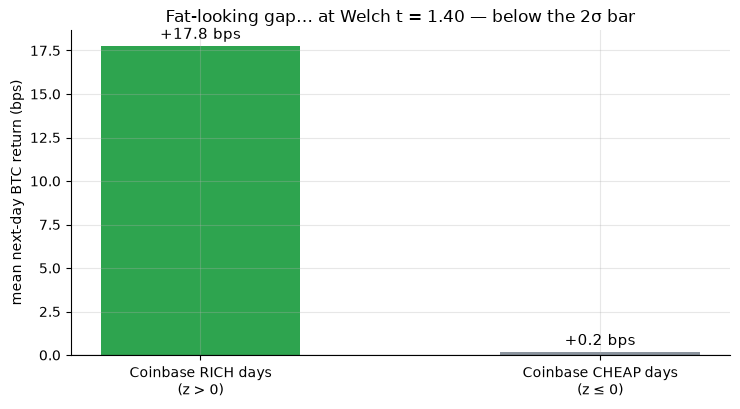

In [4]:
# Next-day BTC return after rich vs cheap premium days (trailing 63d z-score sign).
fig, ax = plt.subplots(figsize=(7.5, 4.2))
vals = [R['split_rich'], R['split_cheap']]
labs = ['Coinbase RICH days\n(z > 0)', 'Coinbase CHEAP days\n(z \u2264 0)']
bars = ax.bar(labs, vals, color=[GREEN, GREY], width=0.5)
for b, v in zip(bars, vals):
    ax.annotate(f'{v:+.1f} bps', (b.get_x() + b.get_width()/2, v + 0.4),
                ha='center', fontsize=11)
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel('mean next-day BTC return (bps)')
ax.set_title('Fat-looking gap… at Welch t = %.2f — below the 2\u03c3 bar' % R['split_welch'])
plt.tight_layout(); plt.show()


## 4 · Trying to trade it anyway

We built the obvious strategy: **hold BTC only when Coinbase is rich** (signal read at tonight's close, position taken for tomorrow — one clean day of lag, no peeking), pay realistic exchange fees on every switch (~76 switches/yr).

| fees (one-way) | strategy, per day | just holding BTC | the *timing* itself worth |
|---|--:|--:|--:|
| 5 bps | +7.4 bps | +8.1 bps | +3.6 bps (1.1σ) |
| 10 bps | +6.3 bps | +8.1 bps | +2.5 bps (0.8σ) |
| 25 bps | +3.2 bps | +8.1 bps | **−0.6 bps** (−0.2σ) |

It **underperforms buy & hold** at every fee level, and the pure timing skill (after matching for how often it's in the market) never gets near significance — a **20-seed coin-flip twin** with the same market time earns ~0, so the machinery isn't hiding anything. The premium is a mirage as a trading signal.

> 💡 It gets worse: the *one* z-score window that looks tradable (20-day, 2.15σ) is flanked by 0.8σ and 1.5σ at 63 and 126 days. When only one knob setting works, you found the knob, not a signal.

## 5 · The ETF twist — smaller, but *sharper*

Since January 2024, US institutions can buy Bitcoin through **spot ETFs** (IBIT & friends) — they no longer need Coinbase to clear dollars. So the premium should be dead, right?

**Wrong — and it's the best result on this tape.** The premium's *size* collapsed (sd ~6-8 bps now vs 60-200 in the early years), but **per basis point it now predicts 22× more** than it did before 2023 — and that sharpening is itself statistically solid (2.7σ). The one era that clears the desk's bar on its own is… **2023 onwards** (2.9σ).

The economics make sense: with mature arbitrage, any *residual* gap that survives is more likely to be real net flow rather than noise. The footprint shrank; its ink got darker.

> 🔬 **For the quants:** pre-2023 slope +0.175 bps/bp vs 2023+ +3.793 bps/bp, HAC-SE difference *t* = +2.72. The 2024+ ETF-era slice alone is *t* = +1.80 — sharper but thin.

## 6 · Verdict

| Axis | Stamp | In one line |
|---|---|---|
| Signal | **WEAK** 🟡 | Right direction everywhere, ~1.4σ where 2 is required; only spec-assisted slices clear the bar |
| Tradability | **MIRAGE** 🔴 | Underperforms holding; timing skill ≈ coin-flip after fees; the good-looking window is a knob artefact |
| "Dead since the ETFs?" | **BUSTED** ⚪ | Compressed 10-20× but 22× sharper per bp — shrunk, not dead |

**Take-home:** the Coinbase premium is a *thermometer*, not a *forecast*. It faithfully shows who is bidding **today** — the 2020-21 institutional wave, the 2026 US absence — but the market has already moved by the time it prints. Folklore promoted a coincident gauge into a leading one; the tape declines the promotion.

*Reproduce every number: `python examples/verify.py` — or go one level deeper in [02_for_the_quants.ipynb](02_for_the_quants.ipynb). Not investment advice.*